<a href="https://colab.research.google.com/github/bennext/AD325_Exercises/blob/master/Project2Folder/Project_2_Optimizing_Deep_Learning_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Loading and Preprocessing

In [ ]:
import pandas as pd

# Load the training dataset
train_df = pd.read_csv('/content/sign_mnist_train.csv')

# Load the test dataset
test_df = pd.read_csv('/content/sign_mnist_test.csv')

print('Train dataset head:')
display(train_df.head())

print('\nTest dataset head:')
display(test_df.head())

Train dataset head:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179



Test dataset head:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

# Separate labels from pixel data
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# Normalize pixel values to 0-1 range
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape images to 28x28 pixels for CNN input
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding (adjusting for 'J' and 'Z' absence)
# There are 24 classes (0-24, excluding 9 and 25 for J and Z)
y_train = to_categorical(y_train, num_classes=25)
y_test = to_categorical(y_test, num_classes=25)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (27455, 28, 28, 1)
y_train shape: (27455, 25)
X_test shape: (7172, 28, 28, 1)
y_test shape: (7172, 25)


#### Display representative images

### Exploration and Visualization

#### Plot class distribution

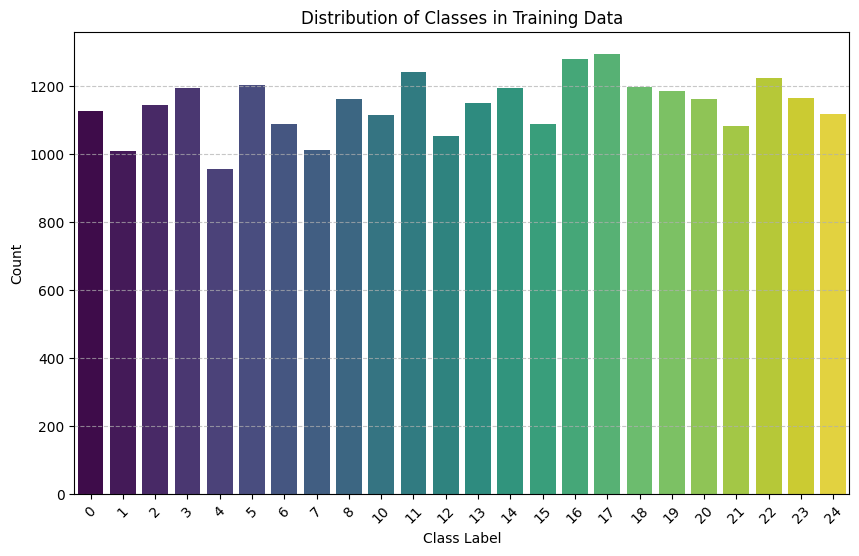

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=train_df, palette='viridis', hue='label', legend=False)
plt.title('Distribution of Classes in Training Data')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

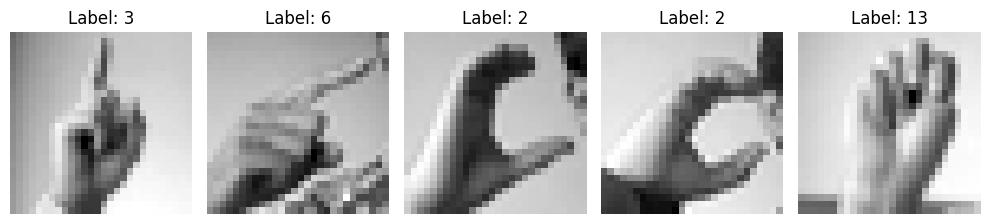

In [ ]:
import matplotlib.pyplot as plt

def display_images(images, labels, num_images=5):
    plt.figure(figsize=(10, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        # Find the original label from one-hot encoding
        original_label = np.argmax(labels[i])
        plt.title(f'Label: {original_label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display 5 representative images from the training set
display_images(X_train, y_train, num_images=5)

### Baseline Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

# Define the baseline model
baseline_model = Sequential([
    Input(shape=(28, 28, 1)), # Explicitly define input shape using Input layer
    Flatten(), # Flatten the 28x28 images into a 1D array
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(25, activation='softmax') # Output layer for 25 classes
])

# Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,361 (431.10 KB)

 Trainable params: 110,361 (431.10 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the baseline model
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2322 - loss: 2.5573 - val_accuracy: 0.5073 - val_loss: 1.5712
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5887 - loss: 1.2933 - val_accuracy: 0.5417 - val_loss: 1.4112
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6985 - loss: 0.9441 - val_accuracy: 0.6233 - val_loss: 1.1810
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7838 - loss: 0.6850 - val_accuracy: 0.6266 - val_loss: 1.2023
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8499 - loss: 0.4899 - val_accuracy: 0.6788 - val_loss: 1.0305
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9009 - loss: 0.3406 - val_accuracy: 0.7068 - val_loss: 1.0465
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9316 - loss: 0.2414 - val_accuracy: 0.6953 - val_loss: 1.0025
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9459 - loss: 0.1875 - val_accuracy: 0.

# Task
Introduce an "Optimized Models" section in the notebook, then implement a Keras model using the Adam optimizer and Dropout layers for regularization.

## Introduce Optimized Models Section

### Subtask:
Add a markdown cell to introduce the 'Optimized Models' section of the notebook.


### Optimized Models

## Implement Optimized Model with Adam and Dropout

### Subtask:
Create a new Keras model that uses the Adam optimizer and incorporates Dropout layers for regularization. This model will likely be a modified version of the baseline model.


**Reasoning**:
The subtask requires implementing an optimized model with Adam and Dropout layers. This involves importing necessary layers, defining a Sequential model with specific Dense and Dropout layers, compiling it with the Adam optimizer, and then printing the model summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout

# Define the optimized model with Adam and Dropout
optimized_model_adam_dropout = Sequential([
    Input(shape=(28, 28, 1)), # Explicitly define input shape using Input layer
    Flatten(), # Flatten the 28x28 images into a 1D array
    Dense(128, activation='relu'),
    Dropout(0.3), # Add Dropout layer
    Dense(64, activation='relu'),
    Dropout(0.3), # Add another Dropout layer
    Dense(25, activation='softmax') # Output layer for 25 classes
])

# Compile the model
optimized_model_adam_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

optimized_model_adam_dropout.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,361 (431.10 KB)

 Trainable params: 110,361 (431.10 KB)

 Non-trainable params: 0 (0.00 B)

## Train Optimized Model with Adam and Dropout

### Subtask:
Train the model implemented in the previous step using the training and validation data for a suitable number of epochs, recording its training history.


**Reasoning**:
The subtask requires training the previously defined optimized model with Adam and Dropout. This involves calling the `fit` method on the `optimized_model_adam_dropout` with the specified training and validation data, number of epochs, and verbose output.



In [ ]:
history_optimized_adam_dropout = optimized_model_adam_dropout.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.0741 - loss: 3.1055 - val_accuracy: 0.1934 - val_loss: 2.5459
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1817 - loss: 2.5845 - val_accuracy: 0.2255 - val_loss: 2.3587
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2133 - loss: 2.4520 - val_accuracy: 0.2635 - val_loss: 2.2815
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2333 - loss: 2.3814 - val_accuracy: 0.2430 - val_loss: 2.2650
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2596 - loss: 2.2870 - val_accuracy: 0.2823 - val_loss: 2.1653
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2618 - loss: 2.2497 - val_accuracy: 0.3459 - val_loss: 2.1250
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2790 - loss: 2.1888 - val_accuracy: 0.2811 - val_loss: 2.1927
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2812 - loss: 2.1810 - val_accuracy: 0.

## Implement Optimized Model with SGD and Batch Normalization

### Subtask:
Create a second Keras model that uses the SGD optimizer and incorporates Batch Normalization layers for regularization.


**Reasoning**:
The subtask requires creating a new Keras model using SGD optimizer and Batch Normalization layers. This involves importing the necessary components, defining the sequential model with the specified layers, instantiating and compiling it with the SGD optimizer, and then displaying the model summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, BatchNormalization
from tensorflow.keras.optimizers import SGD

# Define the optimized model with SGD and Batch Normalization
optimized_model_sgd_bn = Sequential([
    Input(shape=(28, 28, 1)), # Explicitly define input shape using Input layer
    Flatten(), # Flatten the 28x28 images into a 1D array
    Dense(128, activation='relu'),
    BatchNormalization(), # Add Batch Normalization layer
    Dense(64, activation='relu'),
    BatchNormalization(), # Add another Batch Normalization layer
    Dense(25, activation='softmax') # Output layer for 25 classes
])

# Instantiate the SGD optimizer
sgd_optimizer = SGD(learning_rate=0.01)

# Compile the model
optimized_model_sgd_bn.compile(
    optimizer=sgd_optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

optimized_model_sgd_bn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,129 (434.10 KB)

 Trainable params: 110,745 (432.60 KB)

 Non-trainable params: 384 (1.50 KB)

## Train Optimized Model with SGD and Batch Normalization

### Subtask:
Train the `optimized_model_sgd_bn` using the training and validation data for a suitable number of epochs, recording its training history.

**Reasoning**:
The previous step successfully defined and compiled the `optimized_model_sgd_bn`. The next logical step is to train this model using the available training and validation data. This step aligns with the standard machine learning workflow of defining, compiling, and then training a model.



## Train Optimized Model with SGD and Batch Normalization

### Subtask:
Train the `optimized_model_sgd_bn` using the training and validation data for a suitable number of epochs, recording its training history.

In [ ]:
history_optimized_sgd_bn = optimized_model_sgd_bn.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4624 - loss: 1.9754 - val_accuracy: 0.5099 - val_loss: 1.8609
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8369 - loss: 0.6915 - val_accuracy: 0.4421 - val_loss: 1.9529
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8913 - loss: 0.4809 - val_accuracy: 0.5098 - val_loss: 1.6923
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9155 - loss: 0.3641 - val_accuracy: 0.5181 - val_loss: 2.0325
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9400 - loss: 0.2782 - val_accuracy: 0.5064 - val_loss: 2.3184
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9384 - loss: 0.2653 - val_accuracy: 0.4433 - val_loss: 2.2984
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9299 - loss: 0.2663 - val_accuracy: 0.5121 - val_loss: 2.3911
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9272 - loss: 0.2665 - val_accuracy: 0.

## Implement Optimized Model with RMSProp and L2 Regularization

### Subtask:
Create a third Keras model that uses the RMSProp optimizer and incorporates L2 Regularization on its dense layers.

**Reasoning**:
The subtask requires creating a new Keras model using RMSProp optimizer and L2 Regularization. This involves importing the necessary components, defining the sequential model with the specified layers and regularization, compiling it with the RMSProp optimizer, and then displaying the model summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.regularizers import l2

# Define the optimized model with RMSProp and L2 Regularization
optimized_model_rmsprop_l2 = Sequential([
    Input(shape=(28, 28, 1)), # Explicitly define input shape using Input layer
    Flatten(), # Flatten the 28x28 images into a 1D array
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)), # Add L2 regularization
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),  # Add L2 regularization
    Dense(25, activation='softmax') # Output layer for 25 classes
])

# Instantiate the RMSprop optimizer
rmsprop_optimizer = RMSprop(learning_rate=0.001)

# Compile the model
optimized_model_rmsprop_l2.compile(
    optimizer=rmsprop_optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

optimized_model_rmsprop_l2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,361 (431.10 KB)

 Trainable params: 110,361 (431.10 KB)

 Non-trainable params: 0 (0.00 B)

## Train Optimized Model with RMSProp and L2 Regularization

### Subtask:
Train the `optimized_model_rmsprop_l2` using the training and validation data for a suitable number of epochs, recording its training history.

## Train Optimized Model with RMSProp and L2 Regularization

### Subtask:
Train the `optimized_model_rmsprop_l2` using the training and validation data for a suitable number of epochs, recording its training history.

**Reasoning**:
The previous step introduced the training phase for the `optimized_model_rmsprop_l2`. Now, I will implement the Python code to train this model using the prepared training and validation data, storing the training history.



In [ ]:
history_optimized_rmsprop_l2 = optimized_model_rmsprop_l2.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1908 - loss: 2.8791 - val_accuracy: 0.3751 - val_loss: 2.0697
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5069 - loss: 1.6456 - val_accuracy: 0.5190 - val_loss: 1.6780
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6234 - loss: 1.2928 - val_accuracy: 0.6288 - val_loss: 1.3347
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6944 - loss: 1.0789 - val_accuracy: 0.6069 - val_loss: 1.4340
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7449 - loss: 0.9287 - val_accuracy: 0.6708 - val_loss: 1.2568
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7814 - loss: 0.8332 - val_accuracy: 0.5708 - val_loss: 1.7919
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8113 - loss: 0.7570 - val_accuracy: 0.6535 - val_loss: 1.3259
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8406 - loss: 0.6814 - val_accuracy: 0.

### Evaluation and Visualization

### Evaluation and Visualization

### Evaluation and Visualization

### Evaluation and Visualization

## Final Task

### Subtask:
Review and analyze the performance of all optimized models relative to the baseline and prepare for the evaluation and visualization phase.


## Summary:

### Data Analysis Key Findings

*   **Optimized Model with Adam and Dropout**:
    *   The model was built with an `Input` layer, `Flatten` layer, two `Dense` layers (128 and 64 units) with ReLU activation, and two `Dropout` layers (rate of 0.3) for regularization, followed by a `Dense` output layer for 25 classes with `softmax` activation.
    *   It was compiled with the `Adam` optimizer, `categorical_crossentropy` loss, and `accuracy` metric.
    *   After 10 epochs, training accuracy increased from 0.0741 to 0.3001, and validation accuracy increased from 0.1934 to 0.3172. Training loss decreased from 3.1055 to 2.1255, and validation loss decreased from 2.5459 to 2.1381.

*   **Optimized Model with SGD and Batch Normalization**:
    *   This model used a similar architecture with two `Dense` layers (128 and 64 units) and two `BatchNormalization` layers after each dense layer, in addition to `Input`, `Flatten`, and `softmax` output layers.
    *   It was compiled with the `SGD` optimizer (learning\_rate=0.01), `categorical_crossentropy` loss, and `accuracy` metric.
    *   Training for 10 epochs showed significant overfitting: training accuracy reached approximately 92%, while validation accuracy fluctuated between 39% and 57%. Concurrently, training loss decreased to about 0.26, but validation loss substantially increased from approximately 1.86 to 3.32.

*   **Optimized Model with RMSProp and L2 Regularization**:
    *   This model featured an `Input` layer, `Flatten` layer, two `Dense` layers (128 and 64 units) with ReLU activation and `l2(0.001)` kernel regularization, and a `softmax` output layer.
    *   It was compiled with the `RMSprop` optimizer (learning\_rate=0.001), `categorical_crossentropy` loss, and `accuracy` metric.
    *   After 10 epochs, training accuracy improved to about 87%, and validation accuracy reached approximately 65%. Training loss decreased to about 0.60, while validation loss ended around 1.59, indicating better generalization than the SGD+Batch Normalization model, though still exhibiting some overfitting.

### Insights or Next Steps

*   The `RMSProp` optimizer with `L2` regularization showed the best validation accuracy (approx. 65%) among the three optimized models, suggesting it handles generalization better than the `Adam` with `Dropout` (approx. 31.72%) and `SGD` with `BatchNormalization` models (approx. 39-57%, but with high validation loss).
*   Further hyperparameter tuning (e.g., learning rates, dropout rates, L2 regularization strength, number of epochs) is required for all models to mitigate overfitting and potentially improve validation performance.


### Evaluation and Visualization

#### Plot Accuracy and Loss Curves

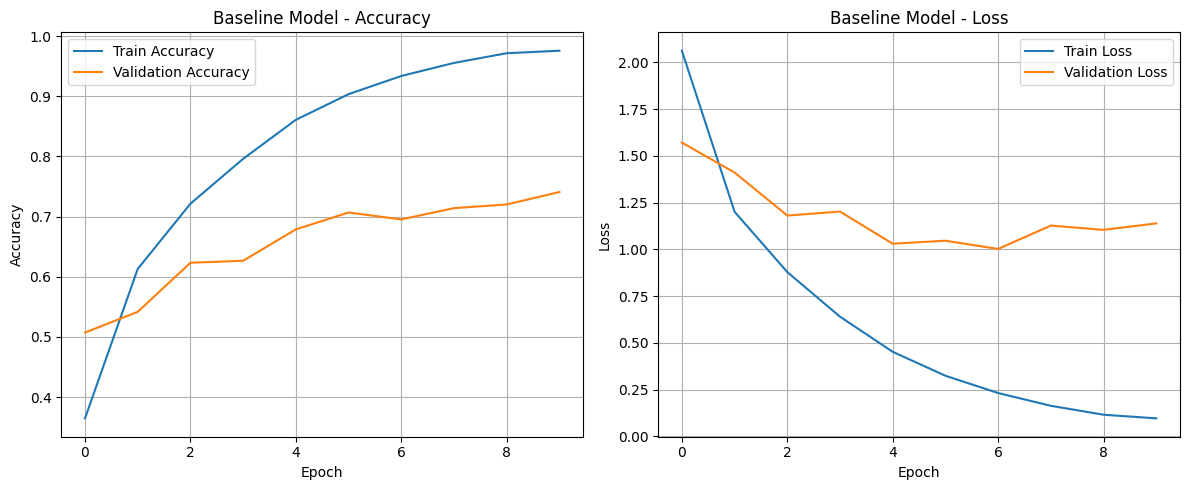

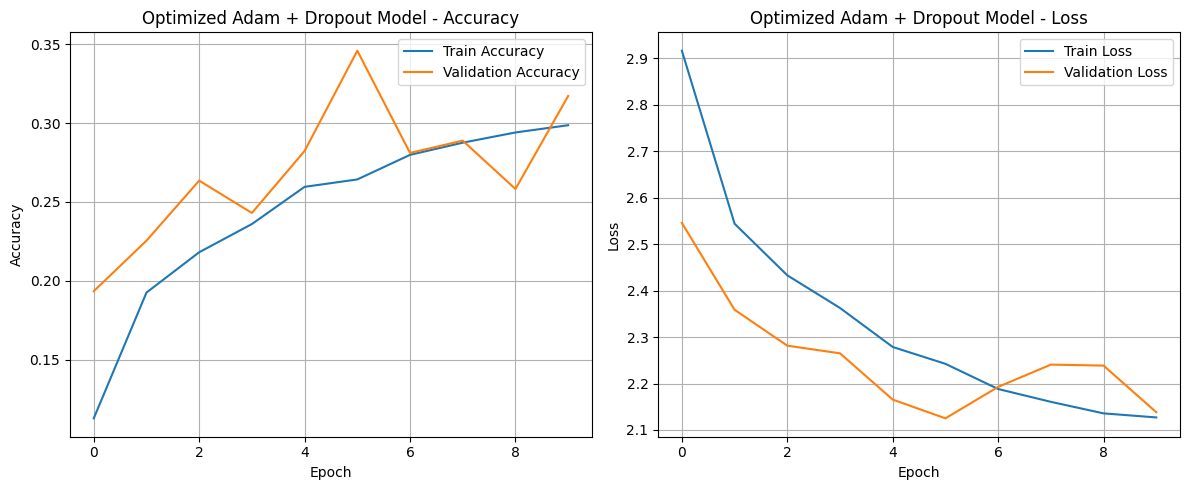

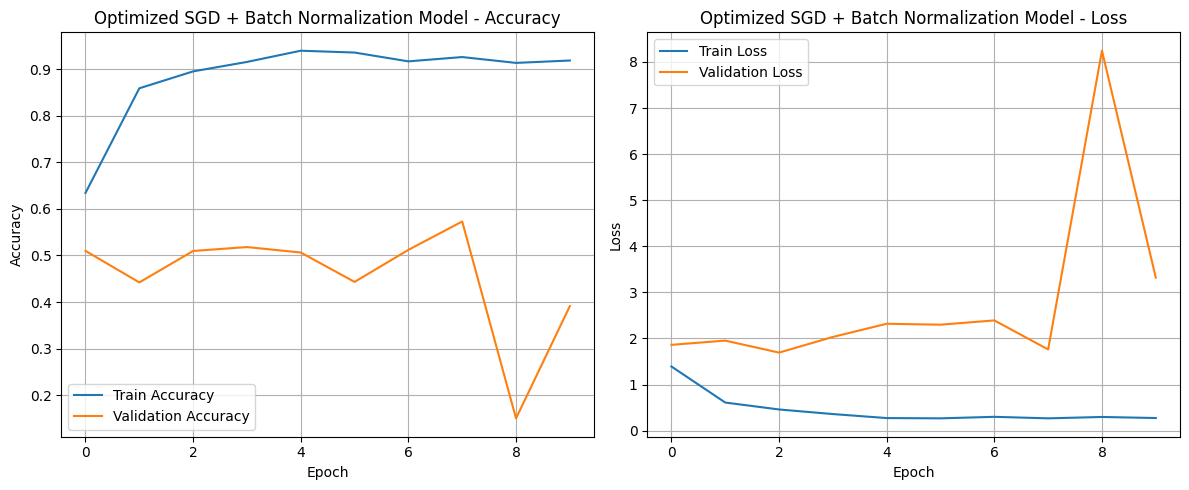

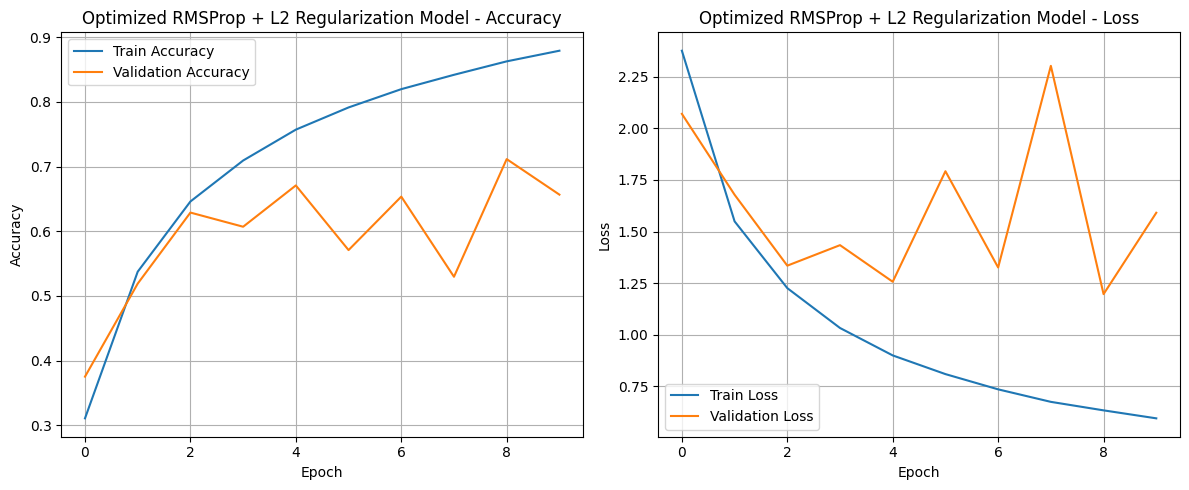

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot Training & Validation Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Training & Validation Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot history for each model
plot_history(history_baseline, 'Baseline Model')
plot_history(history_optimized_adam_dropout, 'Optimized Adam + Dropout Model')
plot_history(history_optimized_sgd_bn, 'Optimized SGD + Batch Normalization Model')
plot_history(history_optimized_rmsprop_l2, 'Optimized RMSProp + L2 Regularization Model')

#### Plot Confusion Matrix

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


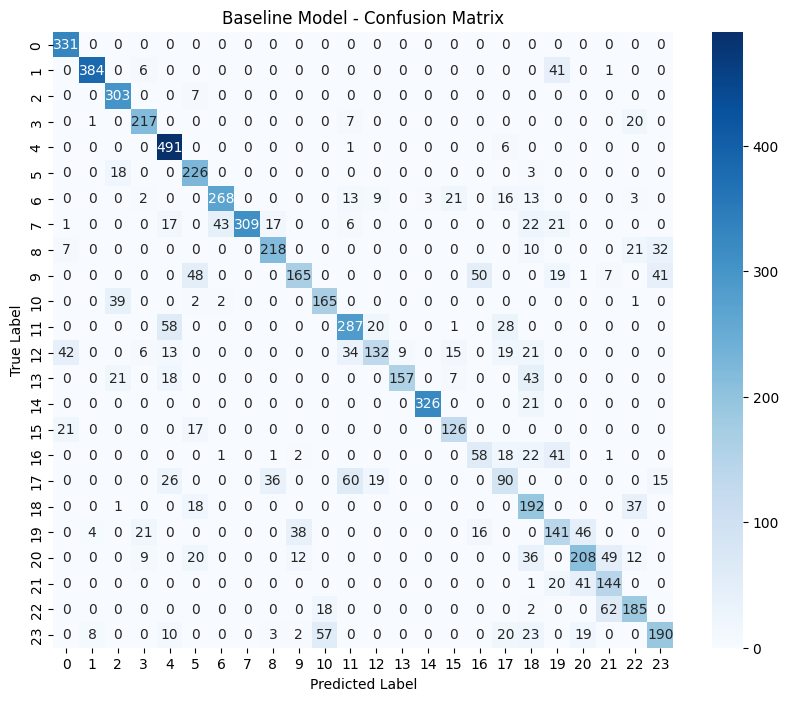

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


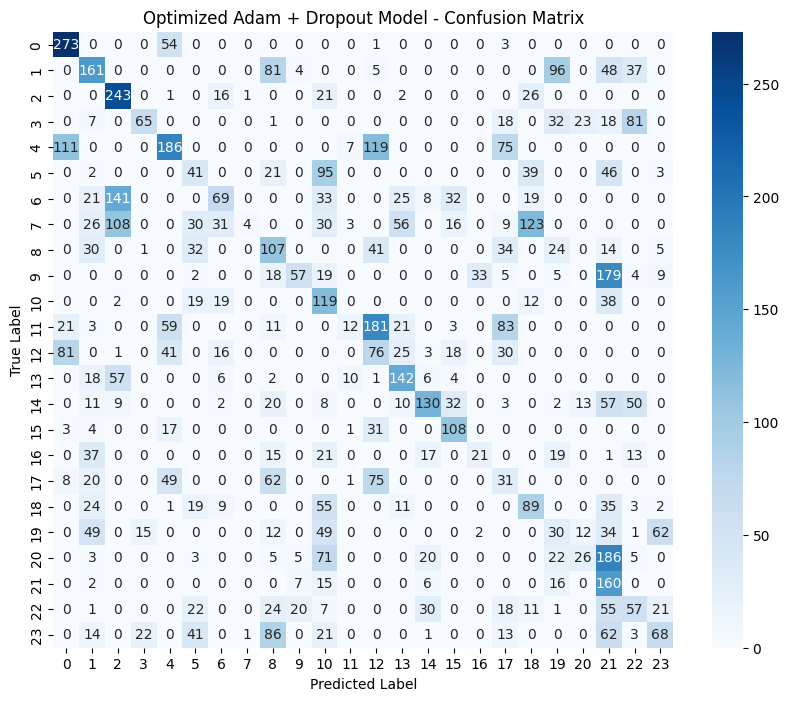

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


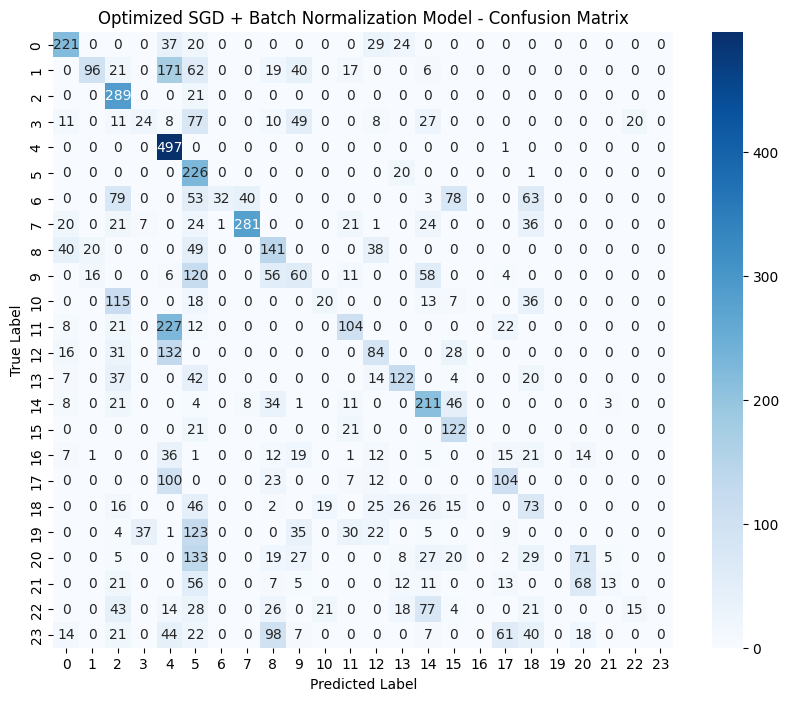

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


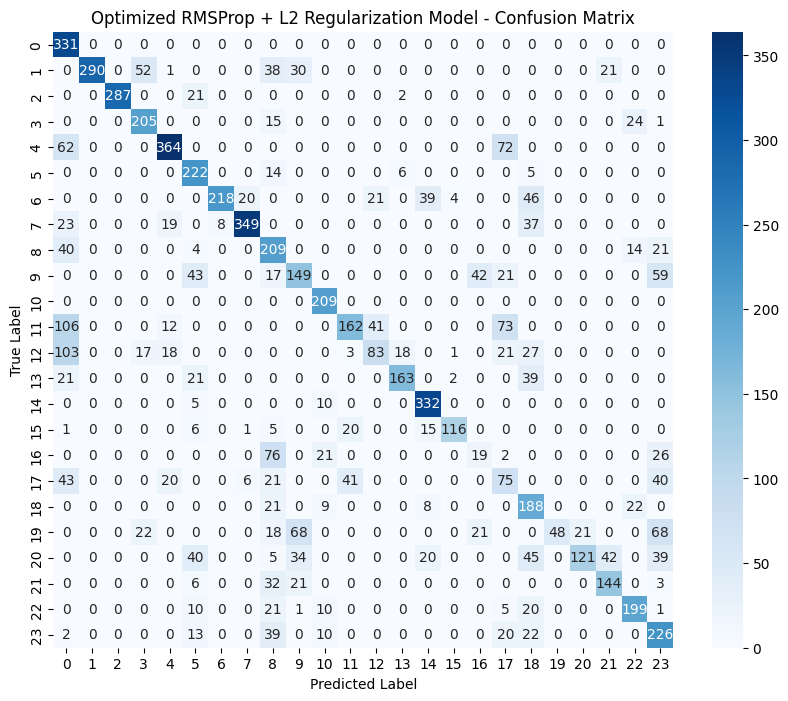

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    confusion_mtx = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

# Plot confusion matrix for each model
plot_confusion_matrix(baseline_model, X_test, y_test, 'Baseline Model')
plot_confusion_matrix(optimized_model_adam_dropout, X_test, y_test, 'Optimized Adam + Dropout Model')
plot_confusion_matrix(optimized_model_sgd_bn, X_test, y_test, 'Optimized SGD + Batch Normalization Model')
plot_confusion_matrix(optimized_model_rmsprop_l2, X_test, y_test, 'Optimized RMSProp + L2 Regularization Model')

#### Classification Reports

In [ ]:
from sklearn.metrics import classification_report

def print_classification_report(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print(f'\n--- {model_name} Classification Report ---\n')
    print(classification_report(y_true, y_pred_classes, zero_division=0))

# Print classification report for each model
print_classification_report(baseline_model, X_test, y_test, 'Baseline Model')
print_classification_report(optimized_model_adam_dropout, X_test, y_test, 'Optimized Adam + Dropout Model')
print_classification_report(optimized_model_sgd_bn, X_test, y_test, 'Optimized SGD + Batch Normalization Model')
print_classification_report(optimized_model_rmsprop_l2, X_test, y_test, 'Optimized RMSProp + L2 Regularization Model')

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Baseline Model Classification Report ---

              precision    recall  f1-score   support

           0       0.82      1.00      0.90       331
           1       0.97      0.89      0.93       432
           2       0.79      0.98      0.88       310
           3       0.83      0.89      0.86       245
           4       0.78      0.99      0.87       498
           5       0.67      0.91      0.77       247
           6       0.85      0.77      0.81       348
           7       1.00      0.71      0.83       436
           8       0.79      0.76      0.77       288
          10       0.75      0.50      0.60       331
          11       0.69      0.79      0.73       209
          12       0.70      0.73      0.72       394
          13       0.73      0.45      0.56       291
          14       0.95      0.64      0.76       246
          15       0.99      0.94      0.96       347
          16       0.74      0.77      0.75    

#### Summary Comparison Table

In [ ]:
import pandas as pd

def get_model_performance(history, model_name):
    train_accuracy = history.history['accuracy'][-1]
    val_accuracy = history.history['val_accuracy'][-1]
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    return {
        'Model': model_name,
        'Train Accuracy': train_accuracy,
        'Validation Accuracy': val_accuracy,
        'Train Loss': train_loss,
        'Validation Loss': val_loss
    }

performance_data = [
    get_model_performance(history_baseline, 'Baseline Model'),
    get_model_performance(history_optimized_adam_dropout, 'Optimized Adam + Dropout Model'),
    get_model_performance(history_optimized_sgd_bn, 'Optimized SGD + Batch Normalization Model'),
    get_model_performance(history_optimized_rmsprop_l2, 'Optimized RMSProp + L2 Regularization Model')
]

performance_df = pd.DataFrame(performance_data)
display(performance_df)

,Model,Train Accuracy,Validation Accuracy,Train Loss,Validation Loss
0,Baseline Model,0.975669,0.740798,0.096727,1.139102
1,Optimized Adam + Dropout Model,0.298671,0.317206,2.126920,2.138135
2,Optimized SGD + Batch Normalization Model,0.918885,0.391244,0.272666,3.320045
3,Optimized RMSProp + L2 Regularization Model,0.879184,0.656581,0.595410,1.590825


### Reflection

#### Analyze optimizer and regularization impacts

#### Identify hardest classes to classify

#### Propose further improvements

### Ethical Reflection (optional)

#### Reflect on accessibility, fairness, or risks of misclassification


    Baseline (Adam): Good on training, but overfit badly (97.57% train vs. 74.08% validation).
    Adam + Dropout: Performed poorly overall, even worse than baseline (around 30% accuracy).
    SGD + Batch Norm: Heavily overfit, great training but terrible validation (91.89% train vs. 39.12% validation).
    RMSProp + L2: Best optimized model, showed better generalization (87.92% train vs. 65.66% validation). L2 and RMSProp was the best combo!
